In [1]:
import numpy as np
import scipy.sparse as sp
from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks, peak_prominences
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from astropy.io import fits
from astropy.stats import sigma_clip
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.visualization import simple_norm
from astropy.wcs import WCS
from spectral_cube import SpectralCube as sc
from sklearn.cluster import DBSCAN
from tqdm.notebook import trange
from kneed import KneeLocator
import os
import time
import warnings
from copy import deepcopy

np.seterr(divide="ignore", invalid="ignore")
np.set_printoptions(precision=10, suppress=True)
plt.rcParams.update({'figure.max_open_warning': 0})
delta_min = 1e-12

%matplotlib widget

In [2]:
# 从data cube导入数据
# HVC_229_234_4_14.fits
# HVC_229_234_4_14.fits

file = "HVC_229_234_4_14.fits"
hdul = fits.open(file)
hdr = hdul[0].header
wcs = WCS(hdr)
data_nan = hdul[0].data.astype(np.float64)
pixel_to_arcmin = (hdr["CDELT2"] * u.deg).to(u.arcmin).value  # 1 pixel = 1.5 arcmin

MEAN = np.nanmean(data_nan)
STD = np.nanstd(data_nan)
print("Mean:", MEAN, "Std:", STD)

data = np.nan_to_num(data_nan)  # 增加这一行可以提升DBSCAN速度至少十倍，尚未知晓原因
print("data.shape =", data.shape)

delta_v = np.float64(hdr["CDELT3"]) / 1000
print(delta_v)

cube = sc.read(hdul)
cube = cube.with_spectral_unit(u.km / u.s)
velocities = cube.spectral_axis.value
cube

# data_slab = deepcopy(data)[3478:, :, :]  # 保留[-600,-100]km/s的速度部分

# 合并相邻两个速度切片的值

# stack = data.shape[0]
# for i in range(0, stack, 2):
#     if i // 2 < stack // 2:
#         data[i // 2] = (data[i] + data[i + 1]) / 2
#
# data = data[: stack // 2]

Mean: 0.019204670654050404 Std: 0.15381578744823923
data.shape = (447, 403, 196)
-0.201283594733


SpectralCube with shape=(447, 403, 196) and unit=K:
 n_x:    196  type_x: GLON-CAR  unit_x: deg    range:   228.966987 deg:  233.842007 deg
 n_y:    403  type_y: GLAT-CAR  unit_y: deg    range:     4.061251 deg:   14.111291 deg
 n_s:    447  type_s: VRAD      unit_s: km / s  range:      100.167 km / s:     189.940 km / s

In [3]:
# hidpi_cube = sc.read('./HI4PI/HI4PI_229_234_4_14.fits')
# hidpi_cube = hidpi_cube.with_spectral_unit(u.km / u.s)
# reprojected_cube = hidpi_cube.reproject(cube.header)
# reprojected_cube.write('./HI4PI/HI4PI_229_234_4_14_reproj.fits', format='fits')

reprojected_cube = sc.read("./HI4PI/HI4PI_229_234_4_14_reproj.fits")
hidpi_data_reproj = reprojected_cube.unmasked_data[:, :, :]

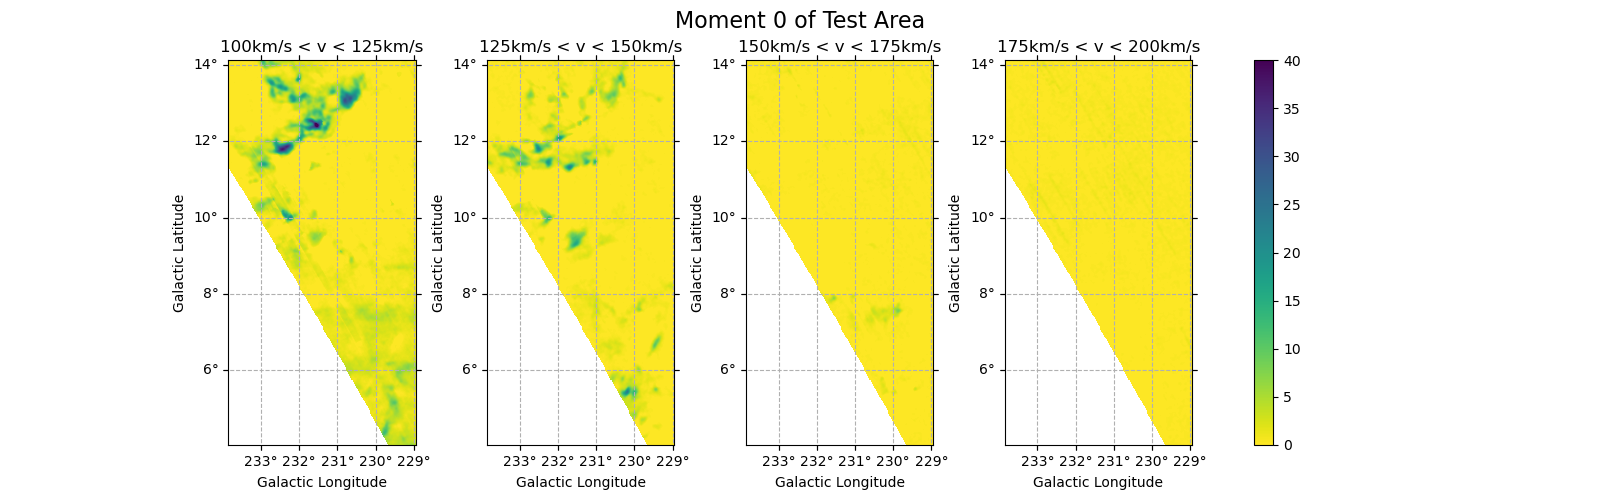

In [4]:
fig, ax = plt.subplots(1, 4, figsize=[16, 5], subplot_kw={"projection": wcs.celestial})

v = np.arange(100, 225, 25)
for i in range(4):
    slab = cube.spectral_slab(v[i + 1] * u.km / u.s, v[i] * u.km / u.s)
    slab_m0 = slab.moment(order=0)
    norm = simple_norm(np.array(slab_m0), vmin=0, vmax=40, stretch="linear")
    ax[i].imshow(np.array(slab_m0), norm=norm, cmap="viridis_r", origin="lower")
    ax[i].grid(linestyle="--")
    # lon = ax[i].coords[0]
    # lat = ax[i].coords[1]
    # lon.set_ticks(spacing=5.0 * u.degree)
    # lon.set_axislabel("RA (J2000)")
    # lat.set_axislabel("DEC (J2000)")
    ax[i].set_title(str(v[i]) + "km/s < v < " + str(v[i + 1]) + "km/s")
    ax[i].set_xlabel("Galactic Longitude")
    ax[i].set_ylabel("Galactic Latitude")

fig.suptitle("Moment 0 of Test Area", fontsize=16)
fig.colorbar(mpl.cm.ScalarMappable(cmap=mpl.cm.viridis_r, norm=norm), ax=ax)

plt.savefig("./Figures/data.png", dpi=300, bbox_inches="tight")
plt.show()

  0%|          | 0/11 [00:00<?, ?it/s]

2.4
0.239


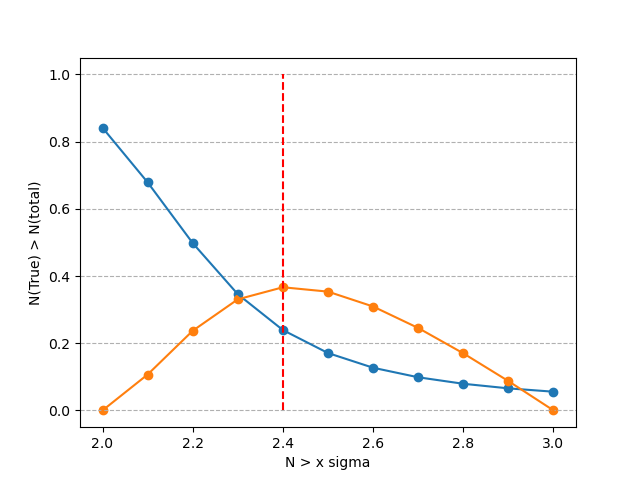

In [ ]:
def test_sigma_clip(test=False):
    if test == True:
        s_ = np.arange(2, 3.1, 0.1)
        y_ = []

        for i in trange(len(s_)):
            filtered_data = sigma_clip(data, sigma=s_[i], maxiters=10, masked=True)
            mask = filtered_data.mask  # True 的元素为 N > 3 sigma
            y_.append(np.count_nonzero(mask) / np.count_nonzero(data))

        kneedle = KneeLocator(s_, y_, S=1.0, curve="convex", direction="decreasing")

        print(round(kneedle.elbow, 3))
        print(round(kneedle.elbow_y, 3))

        fig = plt.figure()
        plt.scatter(s_, y_)
        plt.scatter(s_, kneedle.y_difference)
        plt.plot(s_, y_)
        plt.plot(s_, kneedle.y_difference)
        plt.ylim(-0.05, 1.05)
        plt.vlines(round(kneedle.elbow, 3), 0, 1, ls="--", colors="red")
        plt.xlabel("N > x sigma")
        plt.ylabel("N(True) > N(total)")
        plt.grid(axis="y", ls="--")
        plt.show()
        return kneedle.elbow
    else:
        return 3


s = test_sigma_clip(test=True)  # test=True >> s=2.4

In [ ]:
# 进行sigma clipping，保留 N > sσ 的点

clipped_data = sigma_clip(data, sigma=s, maxiters=10, masked=True)
mask = clipped_data.mask  # True 的元素为 N > sσ
index = np.transpose(np.nonzero(mask)).astype(int)  # N > sσ 的点的坐标[v,y,x]

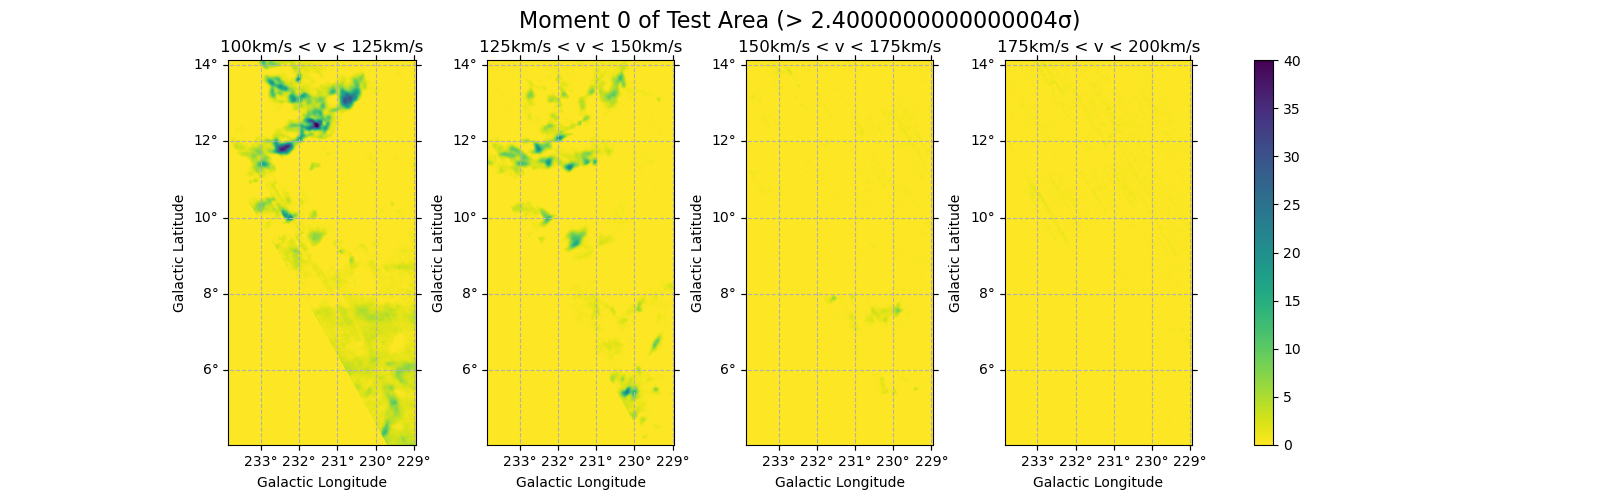

In [ ]:
masked_cube = sc(mask * data, wcs=wcs).with_spectral_unit(u.km / u.s)

fig, ax = plt.subplots(1, 4, figsize=[16, 5], subplot_kw={"projection": wcs.celestial})

v = np.arange(100, 225, 25)
for i in range(4):
    slab = masked_cube.spectral_slab(v[i + 1] * u.km / u.s, v[i] * u.km / u.s)
    slab_m0 = slab.moment(order=0)
    norm = simple_norm(np.array(slab_m0), vmin=0, vmax=40, stretch="linear")
    ax[i].imshow(np.array(slab_m0), norm=norm, cmap="viridis_r", origin="lower")
    ax[i].grid(linestyle="--")
    # lon = ax[i].coords[0]
    # lat = ax[i].coords[1]
    # lon.set_ticks(spacing=5.0 * u.degree)
    # lon.set_axislabel("RA (J2000)")
    # lat.set_axislabel("DEC (J2000)")
    ax[i].set_title(str(v[i]) + "km/s < v < " + str(v[i + 1]) + "km/s")
    ax[i].set_xlabel("Galactic Longitude")
    ax[i].set_ylabel("Galactic Latitude")

fig.suptitle(f"Moment 0 of Test Area (> {s:.1f}σ)", fontsize=16)
fig.colorbar(mpl.cm.ScalarMappable(cmap=mpl.cm.viridis_r, norm=norm), ax=ax)

plt.savefig("./Figures/data_masked.png", dpi=300, bbox_inches="tight")
plt.show()

### 记录表

eps = 1, sqrt(2), sqrt(3)

min_samples = 2, 4, 6,  
              6, 9, 12, 15, 18,  
              9, 12, 15, 18

**记录每一个(eps, min_samples)参数组下，表现最好的SNR/spatial_pixels/FWHM**

N为HVC candidate数目，F为其中的假信号数目，T为其中的真信号数目

| eps | minPts | | SNR | PIX | FWHM | | N | F | T |
| - | - | - | - | - | - | - | - | - | - |
| 3 | 18 |   | 4 | 6 | 4 |   | 13 | 1 | 12 |
| 3 | 15 |   | 4 | 6 | 3.5 |   | 14 | 1 | 12 |
| 3 | 12 |   | 4 | 6 | 3.5 |   | 15 | 2 | 13 |
| 3 | 9 |    | 3.5 | 6 | 3.5 |   | 14 | 2 | 12 |
| 3 | 6 |    | 4 | 6 | 4 |   | 12 | 2 | 10 |
|   |   |    |   |   |   |   |    |   |    |
| 2 | 18 |   | 4 | 6 | 4 |   | 13 | 1 | 12 |
| 2 | 15 |   | 4 | 6 | 3.5 |   | 14 | 1 | 13 |
| 2 | 12 |   | 4 | 6 | 3.5 |   | 15 | 2 | 13 |
| 2 | 9 |    | 4 | 6 | 4 |   | 12 | 2 | 10 |
| 2 | 6 |    | 4 | 6 | 4 |   | 12 | 2 | 10 |
|   |   |    |   |   |   |   |    |   |    |
| 1 | 6 |    | 4 | 6 | 4 |   | 11 | 1 | 10 |
| 1 | 4 |    | 4 | 6 | 5 |   | 10 | 1 | 9 |
| 1 | 2 |    | 4 | 6 | 4 |   | 10 | 1 | 9 |

备注：eps=3，minPts=9时，(131,70)有一个新的候选体，其余参数下并未见到，可能是被淹没于背景

In [8]:
# 调整参数

eps = np.sqrt(3)
min_samples = 12

In [9]:
# DBSCAN 算法
# connectivity=1 eps=1 minPts=4
# connectivity=2 eps=sqrt(2) minPts=8
# connectivity=3 eps=sqrt(3) minPts=11

db = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1).fit(index)
labels = db.labels_  # 输出的是每一个点属于哪个label

# Number of clusters in labels, ignoring noise if present.
unique_labels = set(labels)
n_clusters = len(unique_labels) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters)
print("Estimated number of noise points: %d" % n_noise)

Estimated number of clusters: 43012
Estimated number of noise points: 3004582


In [10]:
# 使用 python 循环计算 moment 0


def calc_moment_0(unique_coords, indices, velo, data):
    moment_0 = np.zeros(len(unique_coords))
    for i in range(len(unique_coords)):  # 对每一个坐标
        m0 = 0
        coo = unique_coords[i]
        for v in velo[indices == i]:  # 对速度轴积分（求和）
            m0 += data[v, coo[0], coo[1]] * abs(delta_v)  # moment 0
        moment_0[i] = m0
    return moment_0


def moment_0_py(data, vyx):
    # Extract the velocity column and the coordinate column separately
    velo = vyx[:, 0]
    coords = vyx[:, 1:]
    # Find unique rows in the x,y columns and their indices
    unique_coords, indices = np.unique(coords, axis=0, return_inverse=True)
    # print(indices) # 旧列表的元素在新列表的位置

    # Calculate moment 0 of the velocity axis
    # for each unique pair of the coordinates
    moment_0 = calc_moment_0(unique_coords, indices, velo, data)
    # Combine the unique coordinates with their moment 0
    moment_0_coo = sp.coo_array(
        (moment_0, (unique_coords[:, 0], unique_coords[:, 1])), shape=data[0].shape
    )
    return moment_0_coo


# 使用 spectral cube 计算 moment 0
# https://github.com/radio-astro-tools/spectral-cube/blob/e98b6c3c05e3a21c6ca62524e1dea9582ad5cd38/spectral_cube/_moments.py#L170


def moment_0_sc(data, vyx):
    bool_array = np.zeros(data.shape, dtype=np.bool)
    bool_array[vyx[:, 0], vyx[:, 1], vyx[:, 2]] = (
        True  # 对第i个cluster的每个点标记为True
    )
    bool_cube = sc(bool_array * data, wcs=wcs).with_spectral_unit(u.km / u.s)
    moment_0 = np.array(bool_cube.moment(order=0))
    # 使用稀疏矩阵（coo_array）储存数据
    moment_0_coo = sp.coo_array(moment_0)
    return moment_0_coo


def moment_0_func(data, index, labels, n_clusters):
    moment_0_cube = np.empty(0)
    for i in trange(n_clusters):
        vyx = index[labels == i]
        size = len(vyx)
        if size > 100000:
            moment_0_coo = moment_0_sc(data, vyx)  # 较大的cluster使用spectral cube更快
        else:
            moment_0_coo = moment_0_py(data, vyx)  # 较小的cluster使用python更快
        moment_0_cube = np.hstack((moment_0_cube, moment_0_coo))
    return moment_0_cube

In [11]:
moment_0_cube = moment_0_func(data, index, labels, n_clusters)

  0%|          | 0/43012 [00:00<?, ?it/s]

In [12]:
# 使用 python 循环计算 moment 1


def calc_moment_1(unique_coords, indices, velo, data):
    moment_1 = np.zeros(len(unique_coords))
    for i in range(len(unique_coords)):  # 对每一个坐标
        m0 = 0
        m1 = 0
        coo = unique_coords[i]
        for v in velo[indices == i]:  # 对速度轴积分（求和）
            m0 += data[v, coo[0], coo[1]]
            vel = velocities[v]
            m1 += data[v, coo[0], coo[1]] * vel  # moment 1
        moment_1[i] = m1 / m0
    return moment_1


def moment_1_py(data, vyx):
    # Extract the velocity column and the coordinate column separately
    velo = vyx[:, 0]
    coords = vyx[:, 1:]
    # Find unique rows in the x,y columns and their indices
    unique_coords, indices = np.unique(coords, axis=0, return_inverse=True)
    # print(indices) # 旧列表的元素在新列表的位置

    # Calculate moment 1 of the velocity axis
    # for each unique pair of the coordinates
    moment_1 = calc_moment_1(unique_coords, indices, velo, data)
    # Combine the unique coordinates with their moment 1
    moment_1_coo = sp.coo_array(
        (moment_1, (unique_coords[:, 0], unique_coords[:, 1])), shape=data[0].shape
    )
    return moment_1_coo

# 使用 spectral cube 计算 moment 1
# https://github.com/radio-astro-tools/spectral-cube/blob/e98b6c3c05e3a21c6ca62524e1dea9582ad5cd38/spectral_cube/_moments.py#L170


def moment_1_sc(data, vyx):
    bool_array = np.zeros(data.shape, dtype=np.bool)
    bool_array[vyx[:, 0], vyx[:, 1], vyx[:, 2]] = (
        True  # 对第i个cluster的每个点标记为True
    )
    bool_cube = sc(bool_array * data, wcs=wcs).with_spectral_unit(u.km / u.s)
    moment_1 = np.array(bool_cube.moment(order=1))
    # 使用稀疏矩阵（coo_array）储存数据
    moment_1_coo = sp.coo_array(moment_1)
    return moment_1_coo


def moment_1_func(data, index, labels, n_clusters):
    moment_1_cube = np.empty(0)
    for i in trange(n_clusters):
        vyx = index[labels == i]
        size = len(vyx)
        if size > 100000:
            moment_1_coo = moment_1_sc(data, vyx)  # 较大的cluster使用spectral cube更快
        else:
            moment_1_coo = moment_1_py(data, vyx)  # 较小的cluster使用python更快
        moment_1_cube = np.hstack((moment_0_cube, moment_1_coo))
    return moment_1_cube

In [13]:
moment_1_cube = moment_1_func(data, index, labels, n_clusters)

  0%|          | 0/43012 [00:00<?, ?it/s]

In [14]:
# 使用 python 循环计算 moment 2 (FWHM)


def calc_moment_2(unique_coords, indices, velo, data):
    moment_2 = np.zeros(len(unique_coords))
    for i in range(len(unique_coords)):  # 对每一个坐标
        m0 = 0
        m1 = 0
        m2 = 0
        coo = unique_coords[i]
        for v in velo[indices == i]:  # 对速度轴积分（求和）
            m0 += data[v, coo[0], coo[1]]
            vel = velocities[v]
            m1 += data[v, coo[0], coo[1]] * vel  # moment 1
        m1 = m1 / m0
        for v in velo[indices == i]:
            vel = velocities[v]
            m2 += data[v, coo[0], coo[1]] * (vel - m1) ** 2  # moment 2
        m2 = np.sqrt(8 * np.log(2) * m2 / m0)  # FWHM
        if np.abs(m2) > delta_min:
            moment_2[i] = m2
        else:
            moment_2[i] = 0
    moment_2 = np.nan_to_num(moment_2)
    return moment_2


def moment_2_py(data, vyx):
    # Extract the velocity column and the coordinate column separately
    velo = vyx[:, 0]
    coords = vyx[:, 1:]
    # Find unique rows in the x,y columns and their indices
    unique_coords, indices = np.unique(coords, axis=0, return_inverse=True)
    # print(indices) # 旧列表的元素在新列表的位置

    # Calculate moment 1 of the velocity axis
    # for each unique pair of the coordinates
    moment_2 = calc_moment_2(unique_coords, indices, velo, data)
    # Combine the unique coordinates with their moment 0
    moment_2_coo = sp.coo_array(
        (moment_2, (unique_coords[:, 0], unique_coords[:, 1])), shape=data[0].shape
    )
    moment_2_coo.eliminate_zeros()
    return moment_2_coo


# 使用 spectral cube 计算 moment 2 (FWHM)
# https://github.com/radio-astro-tools/spectral-cube/blob/e98b6c3c05e3a21c6ca62524e1dea9582ad5cd38/spectral_cube/_moments.py#L170


def moment_2_sc(data, vyx):
    bool_array = np.zeros(data.shape, dtype=np.bool)
    bool_array[vyx[:, 0], vyx[:, 1], vyx[:, 2]] = (
        True  # 对第i个cluster的每个点标记为True
    )
    bool_cube = sc(bool_array * data, wcs=wcs).with_spectral_unit(u.km / u.s)
    moment_2 = np.array(bool_cube.linewidth_fwhm())
    moment_2 = np.nan_to_num(moment_2)
    moment_2[np.abs(moment_2) < delta_min] = 0
    # 使用稀疏矩阵（coo_array）储存数据
    moment_2_coo = sp.coo_array(moment_2)
    return moment_2_coo

def moment_2_func(data, index, labels, n_clusters):
    moment_2_cube = np.empty(0)
    for i in trange(n_clusters):
        vyx = index[labels == i]
        size = len(vyx)
        if size > 100000:
            moment_2_coo = moment_2_sc(data, vyx)  # 较大的cluster使用spectral cube更快
        else:
            moment_2_coo = moment_2_py(data, vyx)  # 较小的cluster使用python更快
        moment_2_cube = np.hstack((moment_2_cube, moment_2_coo))
    return moment_2_cube

In [15]:
moment_2_cube = moment_2_func(data, index, labels, n_clusters)

  0%|          | 0/43012 [00:00<?, ?it/s]

# 筛选符合要求的 HVC 候选体

SNR = 3, 4, 5

spatial_pixels = 4, 6, 9  # SIZE = 3.4, 4.2, 5.1 arcmin

FWHM = 3, 4, 5

In [16]:
MIN_SNR = 3
MIN_PIX = 6
MIN_FWHM = 3
MAX_FWHM = 1000

In [17]:
# 筛选符合要求的 HVC 候选体


def generate_purity_array(arr, MIN_SNR, MIN_PIX, MIN_FWHM):
    # 使用np.all组合条件
    conditions = np.array(
        [
            arr[:, 0] > MIN_SNR,  # SNR
            arr[:, 1] > MIN_PIX,  # spatial pixels
            (arr[:, 2] > MIN_FWHM) & (arr[:, 2] < MAX_FWHM),  # FWHM
        ]
    )
    TF = np.all(conditions, axis=0)  # 在行方向上检查所有条件
    return TF


def calculate_diameter(spatial_pixels):
    pixel_to_arcmin2 = wcs.proj_plane_pixel_area().to(u.arcmin**2).value
    size = spatial_pixels * pixel_to_arcmin2
    diameter = 2 * np.sqrt(size / np.pi)
    return diameter


def purity(data, index, labels, n_clusters):
    result_array = []
    for i in trange(n_clusters):
        vyx = index[labels == i]  # 第i个cluster每个点的坐标
        clu = data[vyx[:, 0], vyx[:, 1], vyx[:, 2]]
        peak = np.max(clu)
        snr = (peak - MEAN) / STD
        coords = vyx[:, 1:3]
        # 找到唯一的(y, x)组合及其出现次数
        unique_yx, counts = np.unique(coords, axis=0, return_counts=True)
        spatial_pixels = len(unique_yx)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            fwhm = np.nanmean(moment_2_cube[i].data)
            #moment_2_coo = moment_2_cube[:, :, i]
            #fwhm = np.mean(moment_2_coo[moment_2_coo > 0])
        result_array.append([snr, spatial_pixels, fwhm])
    result_array = np.nan_to_num(result_array)
    TF = generate_purity_array(result_array, MIN_SNR, MIN_PIX, MIN_FWHM)
    purity_array = np.tile(TF, (3, 1)).T * result_array
    # 使用np.nonzero函数找到非零行的索引
    hvc_candidates = np.nonzero(np.any(purity_array != 0, axis=1))[0]
    # 提取非零行
    SNR = purity_array[hvc_candidates][:, 0]
    SIZE = calculate_diameter(purity_array[hvc_candidates][:, 1])
    FWHM = purity_array[hvc_candidates][:, 2]
    return hvc_candidates, SNR, SIZE, FWHM


hvc_candidates, SNR, SIZE, FWHM = purity(data, index, labels, n_clusters)
hvc_candidates

  0%|          | 0/43012 [00:00<?, ?it/s]

array([ 3986, 13877, 14205, 17940, 18115, 18336, 20237, 21128, 21686,
       22204, 22900, 25059, 28275, 28684, 28770, 38020])

In [18]:
XCEN = []
YCEN = []
XPEAK = []
YPEAK = []
GLON = []
GLAT = []
RA = []
DEC = []
VLSR = []
TPKB = []
FLUX = []

for _i in trange(len(hvc_candidates)):
    i = hvc_candidates[_i]
    vyx = index[labels == i]  # 第i个cluster每个点的vyx坐标
    bool_array = np.zeros(data.shape, dtype=np.bool_)
    bool_array[vyx[:, 0], vyx[:, 1], vyx[:, 2]] = True
    cluster_data = bool_array * data
    center_vyx = np.mean(vyx, axis=0)
    peak_vyx = np.unravel_index(np.argmax(cluster_data), cluster_data.shape)
    peak_coord = wcs.pixel_to_world_values(peak_vyx[2], peak_vyx[1], peak_vyx[0])
    c_gal = SkyCoord(peak_coord[0], peak_coord[1], frame="galactic", unit="deg")
    c_icrs = c_gal.icrs
    flux = np.sum(moment_0_cube[i])
    XCEN.append(center_vyx[2])
    YCEN.append(center_vyx[1])
    XPEAK.append(peak_vyx[2])
    YPEAK.append(peak_vyx[1])
    GLON.append(peak_coord[0])
    GLAT.append(peak_coord[1])
    RA.append(c_icrs.ra.value)
    DEC.append(c_icrs.dec.value)
    VLSR.append(peak_coord[2] / 1000)
    TPKB.append(cluster_data[peak_vyx])
    FLUX.append(flux)

XCEN = np.array(XCEN)
YCEN = np.array(YCEN)
XPEAK = np.round(XPEAK) + 1
YPEAK = np.array(YPEAK) + 1
GLON = np.array(GLON)
GLAT = np.array(GLAT)
RA = np.array(RA)
DEC = np.array(DEC)
VLSR = np.array(VLSR)
VGSR = VLSR + 220 * np.sin(GLON) * np.cos(GLAT)
TPKB = np.array(TPKB)
FLUX = np.array(FLUX)

  0%|          | 0/16 [00:00<?, ?it/s]

In [19]:
# SNR, SIZE, FWHM, GLON, GLAT, RA, DEC, VLSR, VGSR, TPKB, N_HI

CATALOG = pd.DataFrame(
    {
        "ID": hvc_candidates,
        "XPEAK": XPEAK,
        "YPEAK": YPEAK,
        "GLON": GLON,
        "GLAT": GLAT,
        "RA": RA,
        "DEC": DEC,
        "SIZE": SIZE,
        "VLSR": VLSR,
        "VGSR": VGSR,
        "TPKB": TPKB,
        "SNR": SNR,
        "FWHM": FWHM,
        "FLUX": FLUX
    }
)

# CATALOG = CATALOG.sort_values("GLON")
CATALOG

,ID,XPEAK,YPEAK,GLON,GLAT,RA,DEC,SIZE,VLSR,VGSR,TPKB,SNR,FWHM,FLUX
0,3986,58,370,232.417001,13.286288,123.879520,-10.610233,50.295416,177.661355,167.601519,0.880803,5.601496,3.682569,130.591415
1,13877,159,141,229.891991,7.561265,117.571525,-11.382355,56.365560,152.500905,119.010311,0.992052,6.324758,9.371303,1840.844239
2,14205,92,154,231.566998,7.886266,118.706901,-12.658081,19.955171,159.747115,165.357466,0.861619,5.476772,6.587750,145.908613
3,17940,111,134,231.091996,7.386264,118.021809,-12.501375,45.195253,146.864965,49.369340,0.624842,3.937420,6.162499,486.195789
4,18115,147,56,230.191992,5.436257,115.832126,-12.690294,70.134742,136.398218,26.385172,1.519017,9.750702,10.113508,4276.195750
5,18336,177,60,229.441989,5.536257,115.546944,-11.990473,22.581774,143.443144,126.407528,0.776357,4.922461,9.716125,240.875523
6,20237,93,336,231.541997,12.436285,122.690852,-10.320617,186.321739,104.192843,-71.434534,2.712237,17.508168,12.565563,66668.377299
7,21128,16,288,233.467005,11.236280,122.638513,-12.553769,18.150850,146.663681,190.484845,0.522111,3.269536,5.370170,60.127168
8,21686,176,106,229.466989,6.686262,116.582861,-11.447990,33.936034,132.372546,105.993066,0.748745,4.742950,9.377821,656.169146
9,22204,131,105,230.591994,6.661262,117.124841,-12.431861,37.236661,147.468815,-46.929489,0.502755,3.143698,4.642543,246.670273


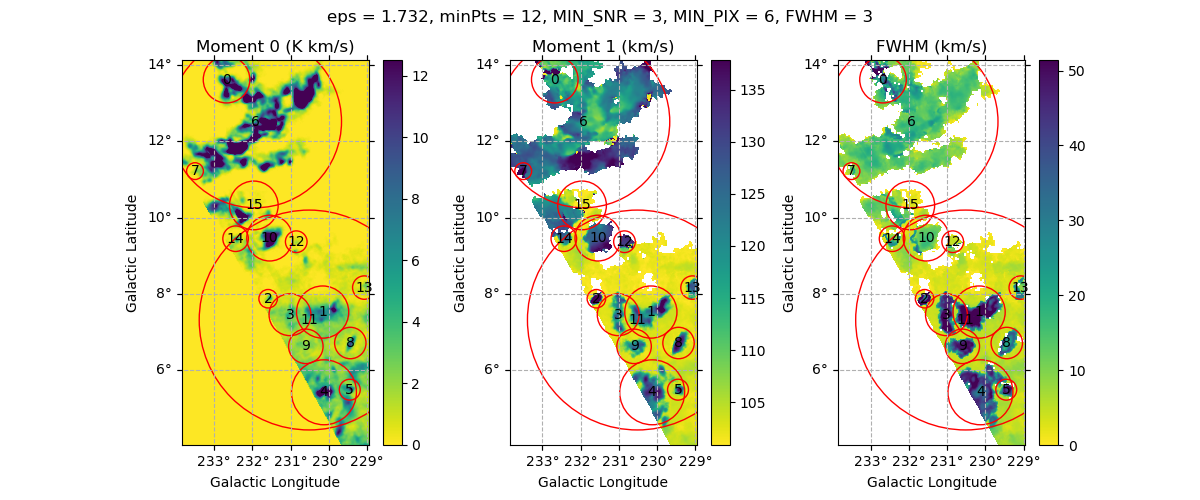

In [20]:
vyx_clusters = np.empty((0, 3))
for i in hvc_candidates:
    vyx = index[labels == i]  # 第i个cluster每个点的vyx坐标
    vyx_clusters = np.vstack((vyx_clusters, vyx))
vyx_clusters = vyx_clusters.astype(int)

bool_array = np.zeros(data.shape, dtype=np.bool_)
bool_array[vyx_clusters[:, 0], vyx_clusters[:, 1], vyx_clusters[:, 2]] = (
    True  # 对第i个cluster的每个点标记为True
)
hvc_candidates_cube = sc(bool_array * data, wcs=wcs).with_spectral_unit(u.km / u.s)

size_pixels = (SIZE / pixel_to_arcmin) ** 2

fig, ax = plt.subplots(
    1, 3, figsize=[12, 5], sharey=True, subplot_kw={"projection": wcs.celestial}
)  # subplot_kw={"projection": wcs.celestial}

moment_0 = np.array(hvc_candidates_cube.moment(order=0))
im0 = ax[0].imshow(
    moment_0, norm=simple_norm(moment_0, percent=95), cmap="viridis_r", origin="lower"
)
ax[0].scatter(XCEN, YCEN, s=size_pixels, c="None", alpha=1, edgecolor="red")
for i, txt in enumerate(hvc_candidates):
    ax[0].annotate(i, (XCEN[i], YCEN[i]), va="center", ha="center")
ax[0].grid(linestyle="--")
ax[0].set_title("Moment 0 (K km/s)")
ax[0].set_xlabel("Galactic Longitude")
ax[0].set_ylabel("Galactic Latitude")
plt.colorbar(im0)

moment_1 = np.array(hvc_candidates_cube.moment(order=1))
im1 = ax[1].imshow(
    moment_1, norm=simple_norm(moment_1, percent=95), cmap="viridis_r", origin="lower"
)
ax[1].scatter(XCEN, YCEN, s=size_pixels, c="None", alpha=1, edgecolor="red")
for i, txt in enumerate(hvc_candidates):
    ax[1].annotate(i, (XCEN[i], YCEN[i]), va="center", ha="center")
ax[1].grid(linestyle="--")
ax[1].set_title("Moment 1 (km/s)")
ax[1].set_xlabel("Galactic Longitude")
ax[1].set_ylabel("Galactic Latitude")
plt.colorbar(im1)

moment_2 = np.array(hvc_candidates_cube.linewidth_fwhm())
im2 = ax[2].imshow(
    moment_2, norm=simple_norm(moment_2, percent=95), cmap="viridis_r", origin="lower"
)
ax[2].scatter(XCEN, YCEN, s=size_pixels, c="None", alpha=1, edgecolor="red")
for i, txt in enumerate(hvc_candidates):
    ax[2].annotate(i, (XCEN[i], YCEN[i]), va="center", ha="center")
ax[2].grid(linestyle="--")
ax[2].set_title("FWHM (km/s)")
ax[2].set_xlabel("Galactic Longitude")
ax[2].set_ylabel("Galactic Latitude")
plt.colorbar(im2)

fig.suptitle(
    f"eps = {np.round(eps, 3)}, minPts = {min_samples}, MIN_SNR = {MIN_SNR}, "
    f"MIN_PIX = {MIN_PIX}, FWHM = {MIN_FWHM}"
)
plt.savefig("./Figures/cluster_moments.png", dpi=300, bbox_inches='tight')
plt.show()

In [21]:
# 对于一个cluster遍历速度轴，对每一个速度v计算所有像素的平均I_v
# 绘制I_v - v光谱图


def calc_spectrum(i, data, index, labels):
    vyx = index[labels == i]  # 第i个cluster每个点的vyx坐标
    bool_array_spec = np.zeros(data.shape, dtype=np.bool_)
    bool_array_spec[:, vyx[:, 1], vyx[:, 2]] = True
    cluster_data = bool_array_spec * data
    cluster_data[cluster_data == 0] = np.nan
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        spectrum = np.nanmean(cluster_data, axis=(1, 2))
    vel_array = spectrum != 0
    vel_array = vel_array * velocities
    non_zero_indices = (spectrum != 0) & (vel_array != 0)
    spectrum = spectrum[non_zero_indices]
    vel_array = vel_array[non_zero_indices]
    return vel_array, spectrum

In [22]:
# HIDPI 的光谱作对比
# 对于一个cluster遍历速度轴，对每一个速度v计算所有像素的平均I_v
# 绘制I_v - v光谱图


vel_array_crafts = []
spectrum_crafts = []

vel_array_hi4pi = []
spectrum_hi4pi = []

for i in hvc_candidates:
    vel_array1, spectrum1 = calc_spectrum(i, data, index, labels)
    vel_array2, spectrum2 = calc_spectrum(i, hidpi_data_reproj, index, labels)
    vel_array_crafts.append(vel_array1)
    spectrum_crafts.append(spectrum1)
    vel_array_hi4pi.append(vel_array2)
    spectrum_hi4pi.append(spectrum2)

### 使用高斯滤波和峰值寻找，根据峰值高度和对称性自动判断光谱信号的真实性

In [23]:
def get_filter(
    x_data: np.ndarray, center: float = 0.0, std: float = 1.0, amp: float = 1.0
):
    # https://stats.stackexchange.com/a/143633
    return amp * np.exp(-((x_data - center) ** 2) / (2 * std**2))


def find_response(x: np.ndarray, y: np.ndarray):
    # Generate the filter you want to match to in the data
    # filter = get_filter(np.linspace(-25, 25, 50), std=3, amp=0.3)
    # y_filtered = np.convolve(y, np.flip(filter), mode='same')
    y_filtered = gaussian_filter(y, sigma=np.mean(FWHM))
    # Use scipy to find all the peaks in the filter response
    peaks, properties = find_peaks(y_filtered)
    # Capture the prominence of each peak (how much does the peak stick up)
    prominences, left_bases, right_bases = peak_prominences(y_filtered, peaks)
    # Find the maximum prominence (which hopefully matches our signal)
    max_prom_index = np.argmax(prominences)
    peak_prominence = prominences[max_prom_index]
    # Find the x-value that the peak occurred at
    main_peak_x = x[peaks[max_prom_index]]
    main_peak_y = y_filtered[peaks[max_prom_index]]
    # the left base of the peak
    main_lbase_x = x[left_bases[max_prom_index]]
    main_lbase_y = y_filtered[left_bases[max_prom_index]]
    # the right base of the peak
    main_rbase_x = x[right_bases[max_prom_index]]
    main_rbase_y = y_filtered[right_bases[max_prom_index]]
    main_peak_plot = [
        main_peak_x,
        main_peak_y,
        main_lbase_x,
        main_lbase_y,
        main_rbase_x,
        main_rbase_y,
    ]
    skew = np.abs(main_peak_plot[2] + main_peak_plot[4] - 2 * main_peak_plot[0])
    skew /= np.abs(main_peak_plot[2] - main_peak_plot[4])
    return y_filtered, main_peak_x, peak_prominence, main_peak_plot, skew

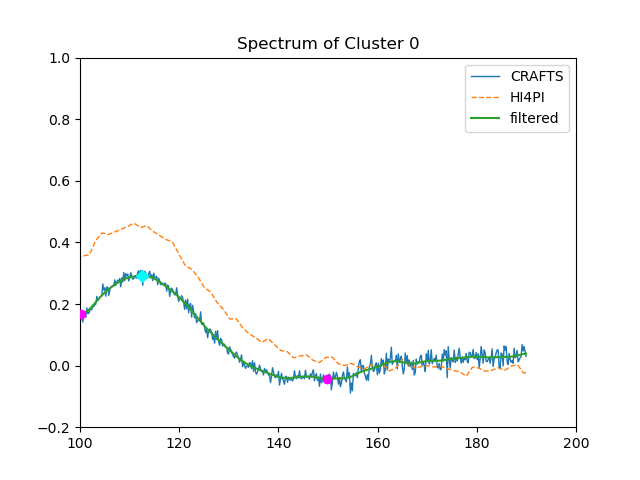

True signal
1 3986 112.44546993068447 0.12471726145369516 0.5060728744939266


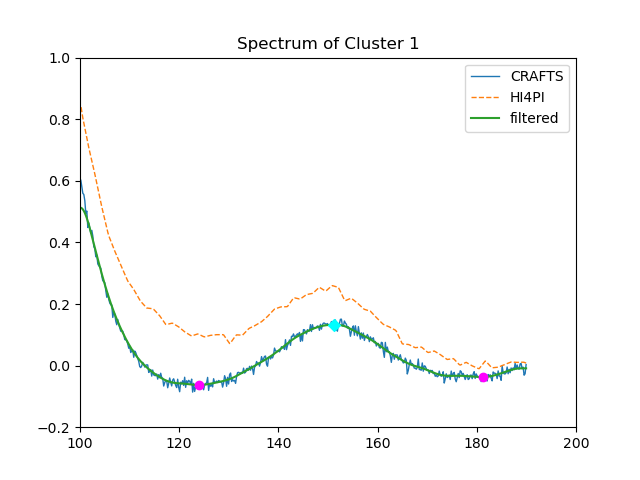

True signal
2 13877 151.29320371415346 0.17020748127135066 0.04561403508771931


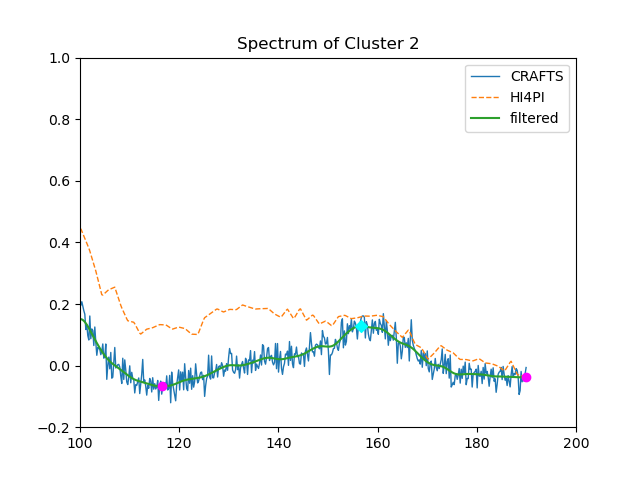

True signal
3 14205 156.72786077194445 0.16695942967070487 0.09589041095890344


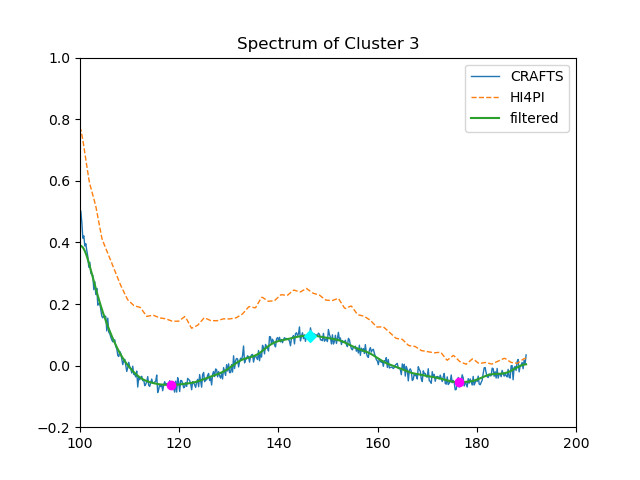

True signal
4 17940 146.4623974405615 0.15151157343127658 0.03114186851210982


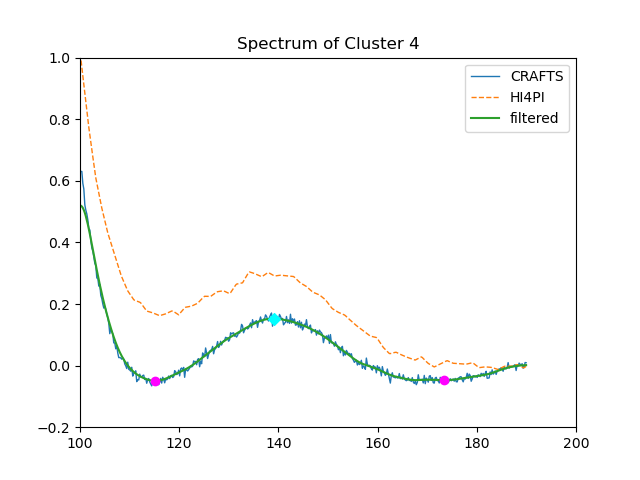

True signal
5 18115 139.01490443544046 0.2000510734984469 0.17931034482758715


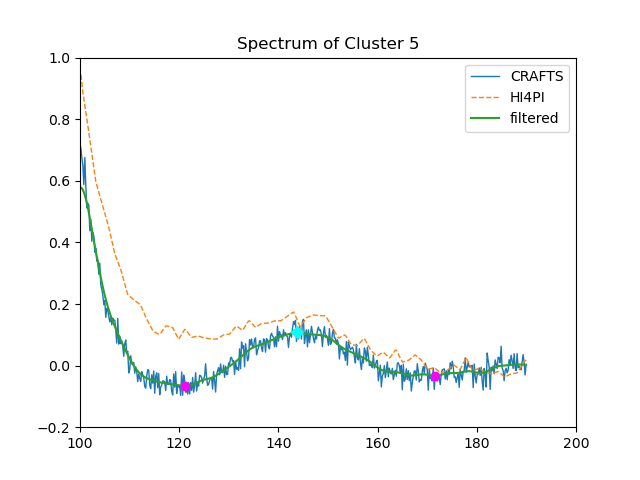

True signal
6 18336 143.8457107090325 0.14104197568673651 0.09960159362549773


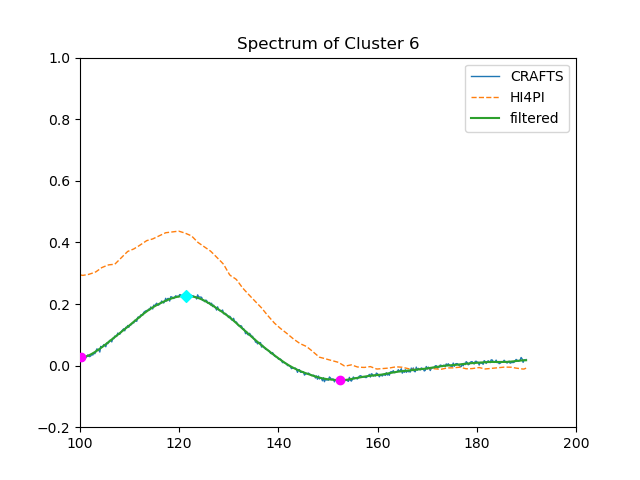

True signal
7 20237 121.30194809893646 0.19964949394159703 0.19230769230769285


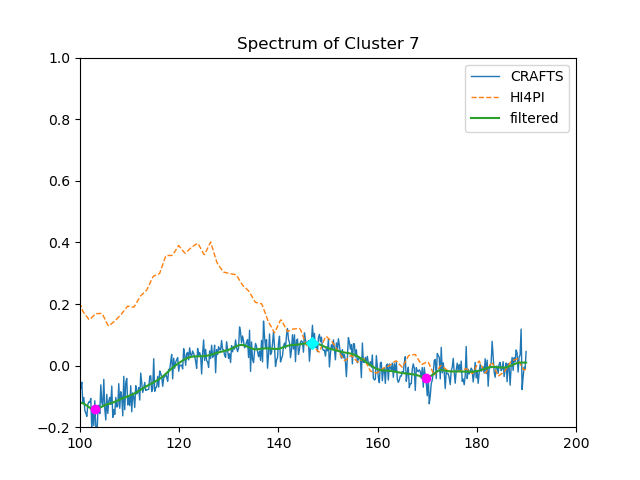

True signal
8 21128 146.8649646300275 0.11294706596458368 0.3132530120481928


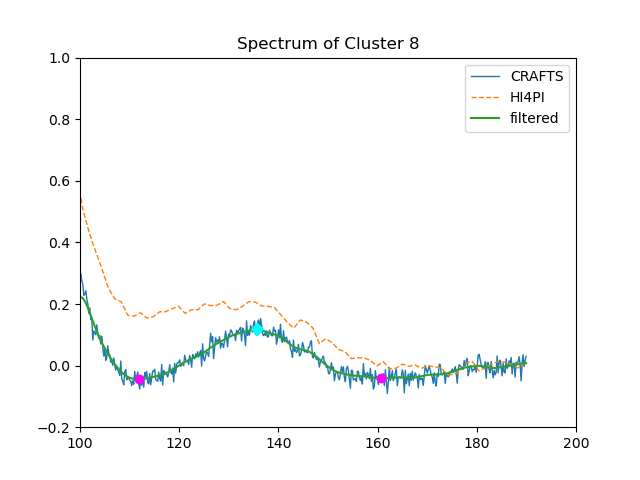

True signal
9 21686 135.59308332497946 0.1590710821557332 0.02880658436214063


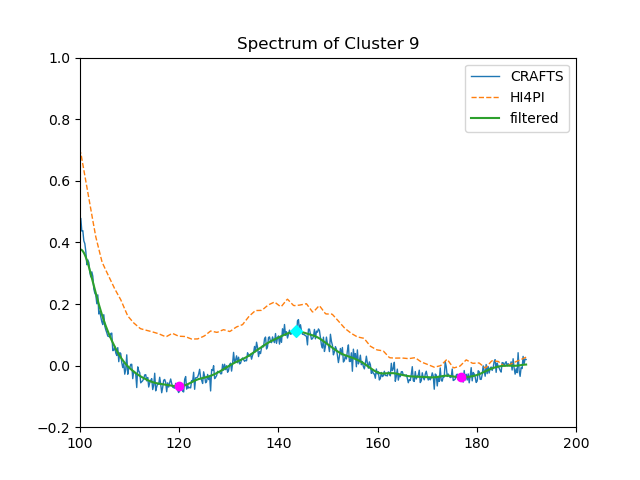

True signal
10 22204 143.64442711429948 0.15009759502634906 0.1660777385159009


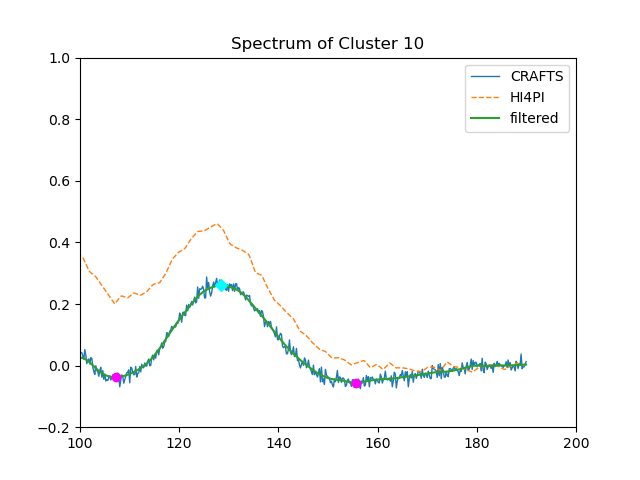

True signal
11 22900 128.34687391459147 0.2975112781759417 0.12863070539419108


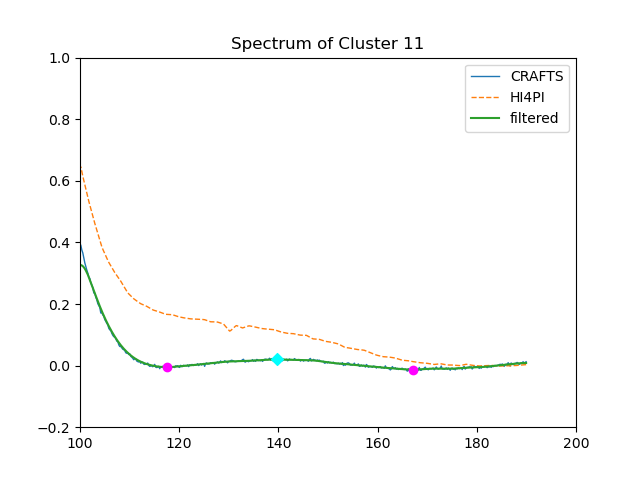

False signal
12 25059 139.61875521963947 0.02496217904275784 0.10931174089068858


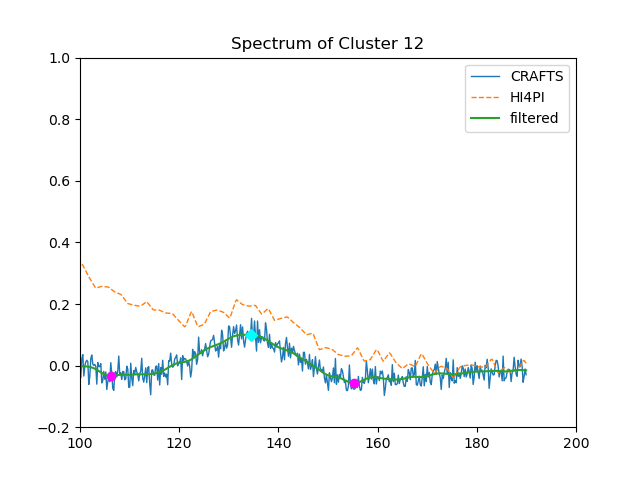

True signal
13 28275 134.3853817565815 0.13443549392390097 0.14754098360655768


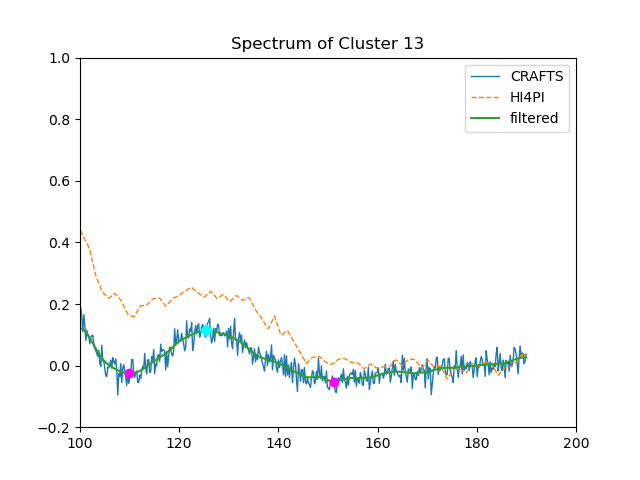

True signal
14 28684 125.32761999359647 0.13909730991990935 0.25242718446601947


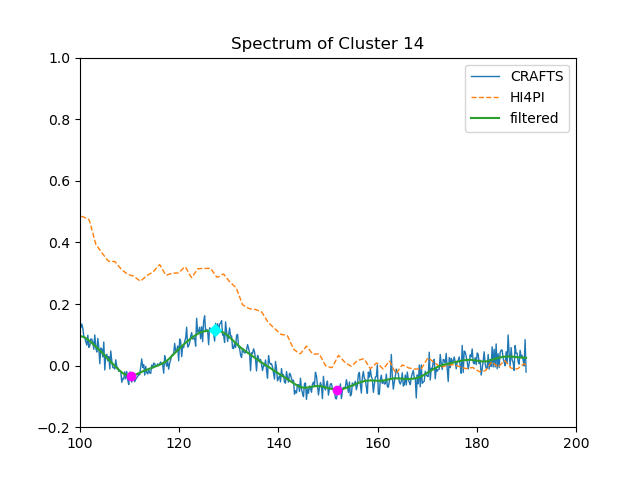

True signal
15 28770 127.13917234619348 0.14752783432494426 0.18840579710144933


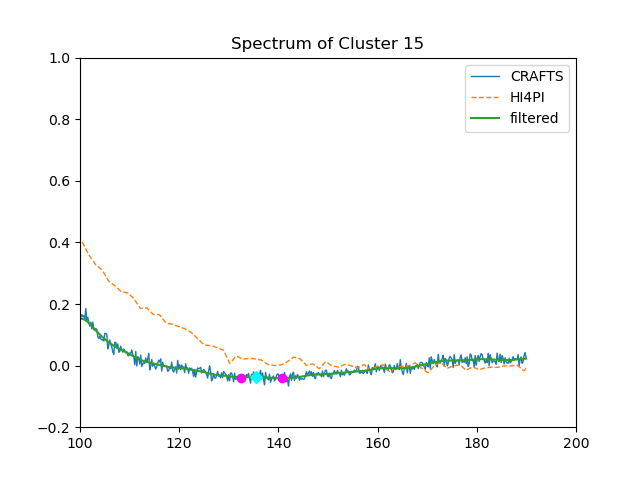

False signal
16 38020 135.39179973024648 0.003236219822887361 0.2857142857142924
N_HVC = 16, F_HVC = 2, T_HVC = 14


In [24]:
N_HVC = len(hvc_candidates)
F_HVC = 0
T_HVC = 0
PEAK_HEIGHT = []
PEAK_WIDTH = []

for i in range(len(vel_array_crafts)):
    y_filtered, v_peak, peak_prominence, main_peak_plot, skew = find_response(
        vel_array_crafts[i], spectrum_crafts[i]
    )
    fig = plt.figure()
    plt.plot(vel_array_crafts[i], spectrum_crafts[i], label="CRAFTS", lw=1)
    plt.plot(vel_array_hi4pi[i], spectrum_hi4pi[i], label="HI4PI", lw=1, ls="--")
    plt.plot(vel_array_crafts[i], y_filtered, label="filtered", lw=1.5)
    # plt.scatter(x[peaks], y_filtered[peaks], c="cyan", marker="+")
    plt.scatter(
        main_peak_plot[0],
        main_peak_plot[1],
        c="cyan",
        marker="D",
        zorder=100,
    )
    # plt.scatter(x[left_bases], y_filtered[left_bases], c="magenta", marker="+")
    plt.scatter(
        main_peak_plot[2],
        main_peak_plot[3],
        c="magenta",
        zorder=100,
    )
    # plt.scatter(x[right_bases], y_filtered[right_bases], c="magenta", marker="+")
    plt.scatter(
        main_peak_plot[4],
        main_peak_plot[5],
        c="magenta",
        zorder=100,
    )
    plt.legend()
    plt.xlim(100, 200)
    plt.ylim(-0.2, 1)
    plt.title(f"Spectrum of Cluster {i}")
    plt.show()
    if peak_prominence > 0.1 and skew < 0.6:
        print("True signal")
        PEAK_HEIGHT.append(peak_prominence)
        PEAK_WIDTH.append(np.abs(main_peak_plot[2] - main_peak_plot[4]))
    else:
        print("False signal")
        F_HVC += 1
    print(i + 1, hvc_candidates[i], v_peak, peak_prominence, skew)


T_HVC = N_HVC - F_HVC
print(f"N_HVC = {N_HVC}, F_HVC = {F_HVC}, T_HVC = {T_HVC}")